In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Grid and escape radius for Mandelbrot set (c such that z_{n+1} = z_n^2 + c stays bounded)
X = np.linspace(-2.0, 1.0, 1000)
Y = np.linspace(-1.0, 1.0, 1000)
z_tol = 2
max_iter = 50

X_grid, Y_grid = np.meshgrid(X, Y)
Z_grid = X_grid + Y_grid * 1j


def mandelbrot_sequence(c_grid, num_iters):
    """
    Vectorized Mandelbrot iteration: z_{n+1} = z_n^2 + c with z_0 = 0.
    Returns the final z values (used for coloring by magnitude).
    """
    z = np.zeros_like(c_grid, dtype=complex)
    for _ in range(num_iters):
        mask = np.abs(z) <= z_tol
        z = np.where(mask, z * z + c_grid, z)
    return z

In [3]:
Z_hit = np.abs(mandelbrot_sequence(Z_grid, max_iter))
Z_hit = np.minimum(Z_hit, z_tol)  # cap escaped points for consistent coloring

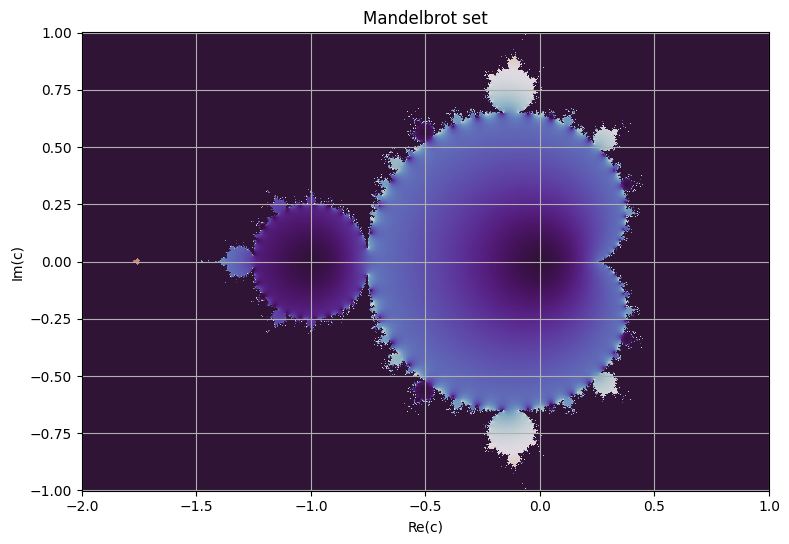

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.pcolormesh(X_grid, Y_grid, Z_hit, cmap="twilight_shifted")
ax.set_xlabel("Re(c)")
ax.set_ylabel("Im(c)")
ax.set_title("Mandelbrot set")
ax.grid(True)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()